In [ ]:
%pip install seaborn

# "C:\Users\User\Desktop\Machine Learning\dataset1_cleaned_numeric.csv"

Class distribution:
Pass
1    5155
0    1452
Name: count, dtype: int64

Predicted classes: [0 1 1 1 0 1 0 0 1 1 1 0 1 0 1 1 1 0 1 0]

Predicted probabilities: [0.20466654 0.86963726 0.99970405 0.99996589 0.40642721 0.96692407
 0.07216376 0.01736383 0.97740413 0.84510444 0.90890314 0.10796658
 0.95692243 0.23046291 0.99997432 0.83312758 0.81483112 0.35277602
 0.99340396 0.05372253]

Actual classes: [0 0 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0]
Using threshold = 0.6

Accuracy: 0.8451840645486637

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.92      0.72       436
           1       0.97      0.82      0.89      1547

    accuracy                           0.85      1983
   macro avg       0.78      0.87      0.81      1983
weighted avg       0.89      0.85      0.86      1983


Feature Importance (Balanced Logistic Coefficients):
Hours_Studied: 2.212623273800894
Attendance: 2.985890945815165
Sleep_Hours: 0.01347009497939675
Pre

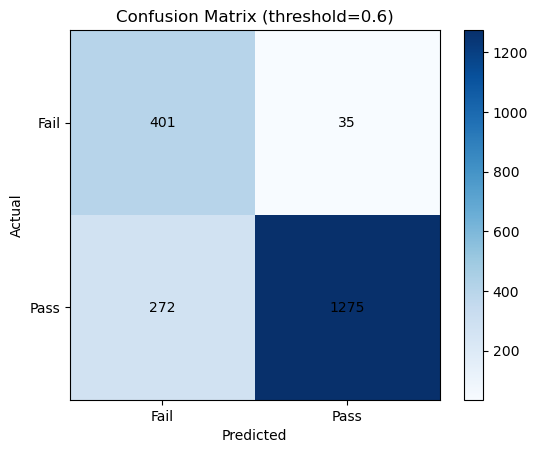

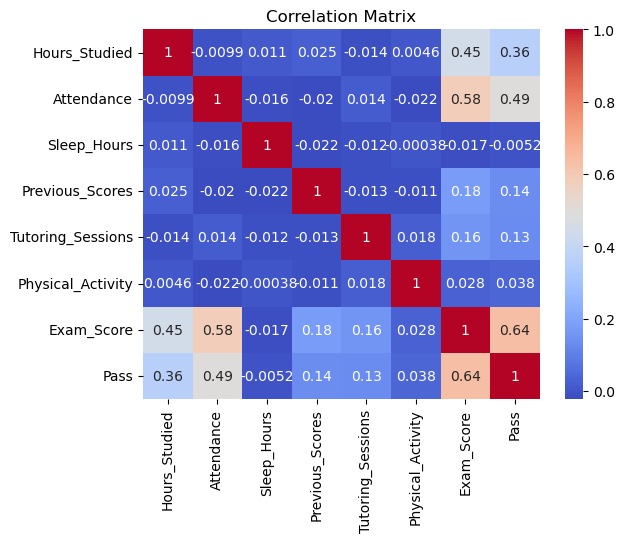

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv("C:/Users/User/Desktop/Machine Learning/dataset1_cleaned_numeric.csv")

# -------------------------
# Create Pass/Fail column
# Save the new dataset
# Pass = 1 if Exam_Score >= 65
# Fail = 0 if Exam_Score < 65
# -------------------------
df["Pass"] = (df["Exam_Score"] >= 65).astype(int)
Altered_path = "C:/Users/User/Machine/Jupyter file/Supervised learning/dataset1_cleaned_altered.csv"
df.to_csv(Altered_path, index = False)

# -------------------------
# Features and target
# -------------------------
X = df.drop(["Exam_Score", "Pass"], axis=1)
y = df["Pass"]

print("Class distribution:")
print(y.value_counts())

# -------------------------
# Train/test split
# -------------------------
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------
# Scale features
# -------------------------
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# -------------------------
# Train BALANCED logistic regression
# -------------------------
model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(x_train_scaled, y_train)

# -------------------------
# Predictions
# -------------------------
y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:, 1]

print("\nPredicted classes:", y_pred[:20])
print("\nPredicted probabilities:", y_prob[:20])
print("\nActual classes:", y_test.values[:20])

# -------------------------
# Evaluation
# -------------------------
threshold = 0.6
y_pred = (y_prob >= threshold).astype(int)

print("Using threshold =", threshold)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------
# Coefficients
# -------------------------
print("\nFeature Importance (Balanced Logistic Coefficients):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef}")

print("Intercept:", model.intercept_[0])

# -------------------------
# Confusion Matrix
# -------------------------

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix (threshold={threshold})")
plt.colorbar()

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#--------------------------------
# correlation
#--------------------------------


corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


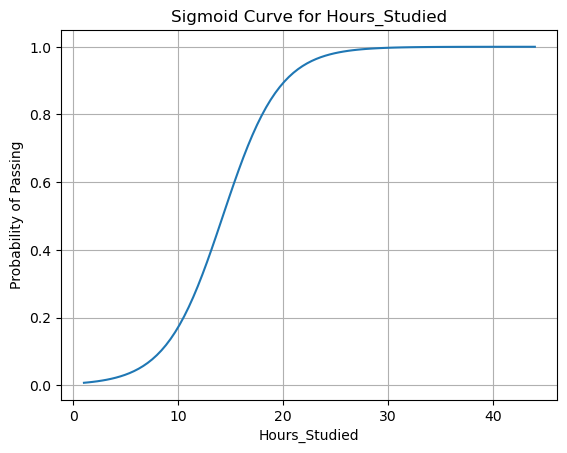

In [4]:


#---------------------------------------------
# Sigmoid curve for Hours studied
#---------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Choose one feature to visualize
feature_name = "Hours_Studied"
feature_index = list(X.columns).index(feature_name)

# Create range of values for that feature
x_values = np.linspace(X[feature_name].min(), X[feature_name].max(), 100)

# Create a baseline (mean values for all features)
X_mean = np.mean(x_train_scaled, axis=0)

# Replace chosen feature with varying values
X_plot = np.tile(X_mean, (100, 1))
X_plot[:, feature_index] = (x_values - X[feature_name].mean()) / X[feature_name].std()

# Get probabilities
y_probs = model.predict_proba(X_plot)[:, 1]

# Plot sigmoid curve
plt.plot(x_values, y_probs)
plt.xlabel(feature_name)
plt.ylabel("Probability of Passing")
plt.title(f"Sigmoid Curve for {feature_name}")
plt.grid()
plt.show()

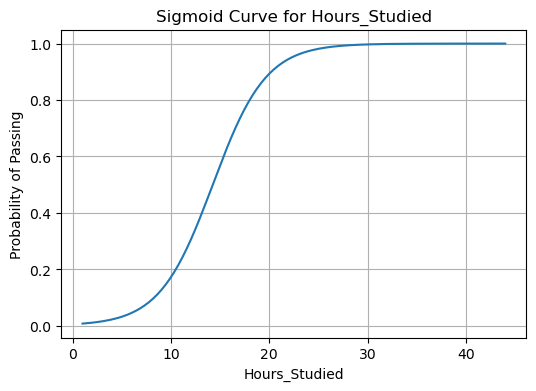

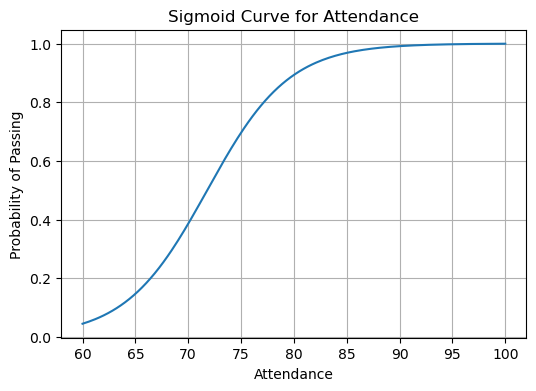

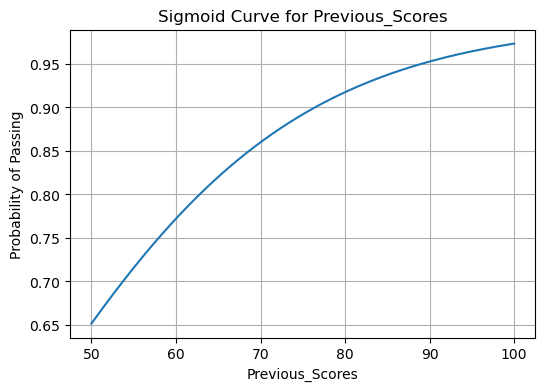

In [7]:
import numpy as np
import matplotlib.pyplot as plt

top_features = ["Hours_Studied", "Attendance", "Previous_Scores"]

for feature_name in top_features:
    feature_index = list(X.columns).index(feature_name)

    # original feature range
    x_values = np.linspace(X[feature_name].min(), X[feature_name].max(), 200)

    # start from average scaled feature values
    X_mean_scaled = np.mean(x_train_scaled, axis=0)
    X_plot = np.tile(X_mean_scaled, (200, 1))

    # vary only one feature, keep others fixed
    feature_mean = X[feature_name].mean()
    feature_std = X[feature_name].std()

    X_plot[:, feature_index] = (x_values - feature_mean) / feature_std

    # get predicted probabilities
    y_probs = model.predict_proba(X_plot)[:, 1]

    # plot
    plt.figure(figsize=(6,4))
    plt.plot(x_values, y_probs)
    plt.xlabel(feature_name)
    plt.ylabel("Probability of Passing")
    plt.title(f"Sigmoid Curve for {feature_name}")
    plt.grid()
    plt.show()